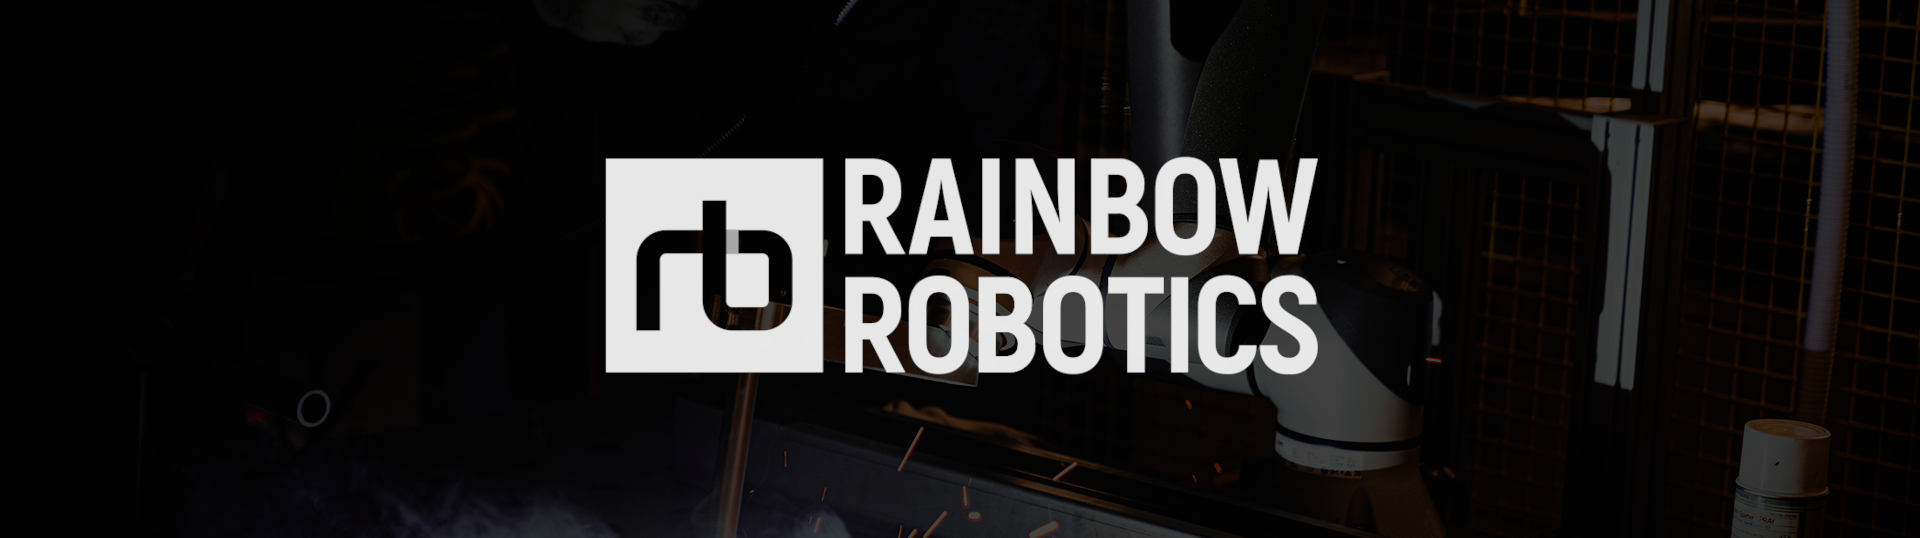

In [1]:
! pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 15.6 MB/s  0:00:00 16.2 MB/s eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 16.6 MB/s  0:00:00 16.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 15.1 MB/s  0:00:005.7 MB/s eta 0:00:01
Using cached pyparsing-3.3.3-py3-none-any.whl (126 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ow]


In [2]:
import rbpodo as rb

In [3]:
import time
import numpy as np
from matplotlib import pyplot as plt

print("Hello, World!")

Hello, World!


In [4]:
ROBOT_ADDRESS = "10.0.2.6"

robot = rb.Cobot(ROBOT_ADDRESS)
data_channel = rb.CobotData(ROBOT_ADDRESS)

In [5]:
rc = rb.ResponseCollector()

In [8]:
robot.set_operation_mode(rc, rb.OperationMode.Simulation)
robot.set_speed_bar(rc, 1.0)

{ "type": Success, "remain_time": -1 }

In [9]:
blending_value = [0.01, 5.0, 20.0, 50.0]
q = []

for bv in blending_value:
    robot.move_jb2_clear(rc)
    robot.move_jb2_add(rc, np.array([90, 0, 0, 0, 0, 0]), 100, 100, bv)
    robot.move_jb2_add(rc, np.array([0, 0, 0, 0, 0, 0]), 100, 100, bv)
    robot.move_jb2_add(rc, np.array([90, 0, 0, 0, 0, 0]), 100, 100, bv)
    robot.move_jb2_add(rc, np.array([0, 0, 0, 0, 0, 0]), 100, 100, bv)
    robot.move_jb2_add(rc, np.array([90, 0, 0, 0, 0, 0]), 100, 100, bv)
    
    robot.flush(rc)
    robot.move_jb2_run(rc)

    data = []
    if robot.wait_for_move_started(rc, 0.5).type() == rb.ReturnType.Success:
        while robot.wait_for_move_finished(rc, 0.).type() == rb.ReturnType.Timeout:
            data.append(data_channel.request_data().sdata.jnt_ref)
            time.sleep(0.01)
        q.append(np.squeeze(np.array(data)[:, 0]))
q = np.vstack([np.hstack((e, np.tile(e[-1], max([e.shape[0] for e in q]) - e.shape[0]))) for e in q])

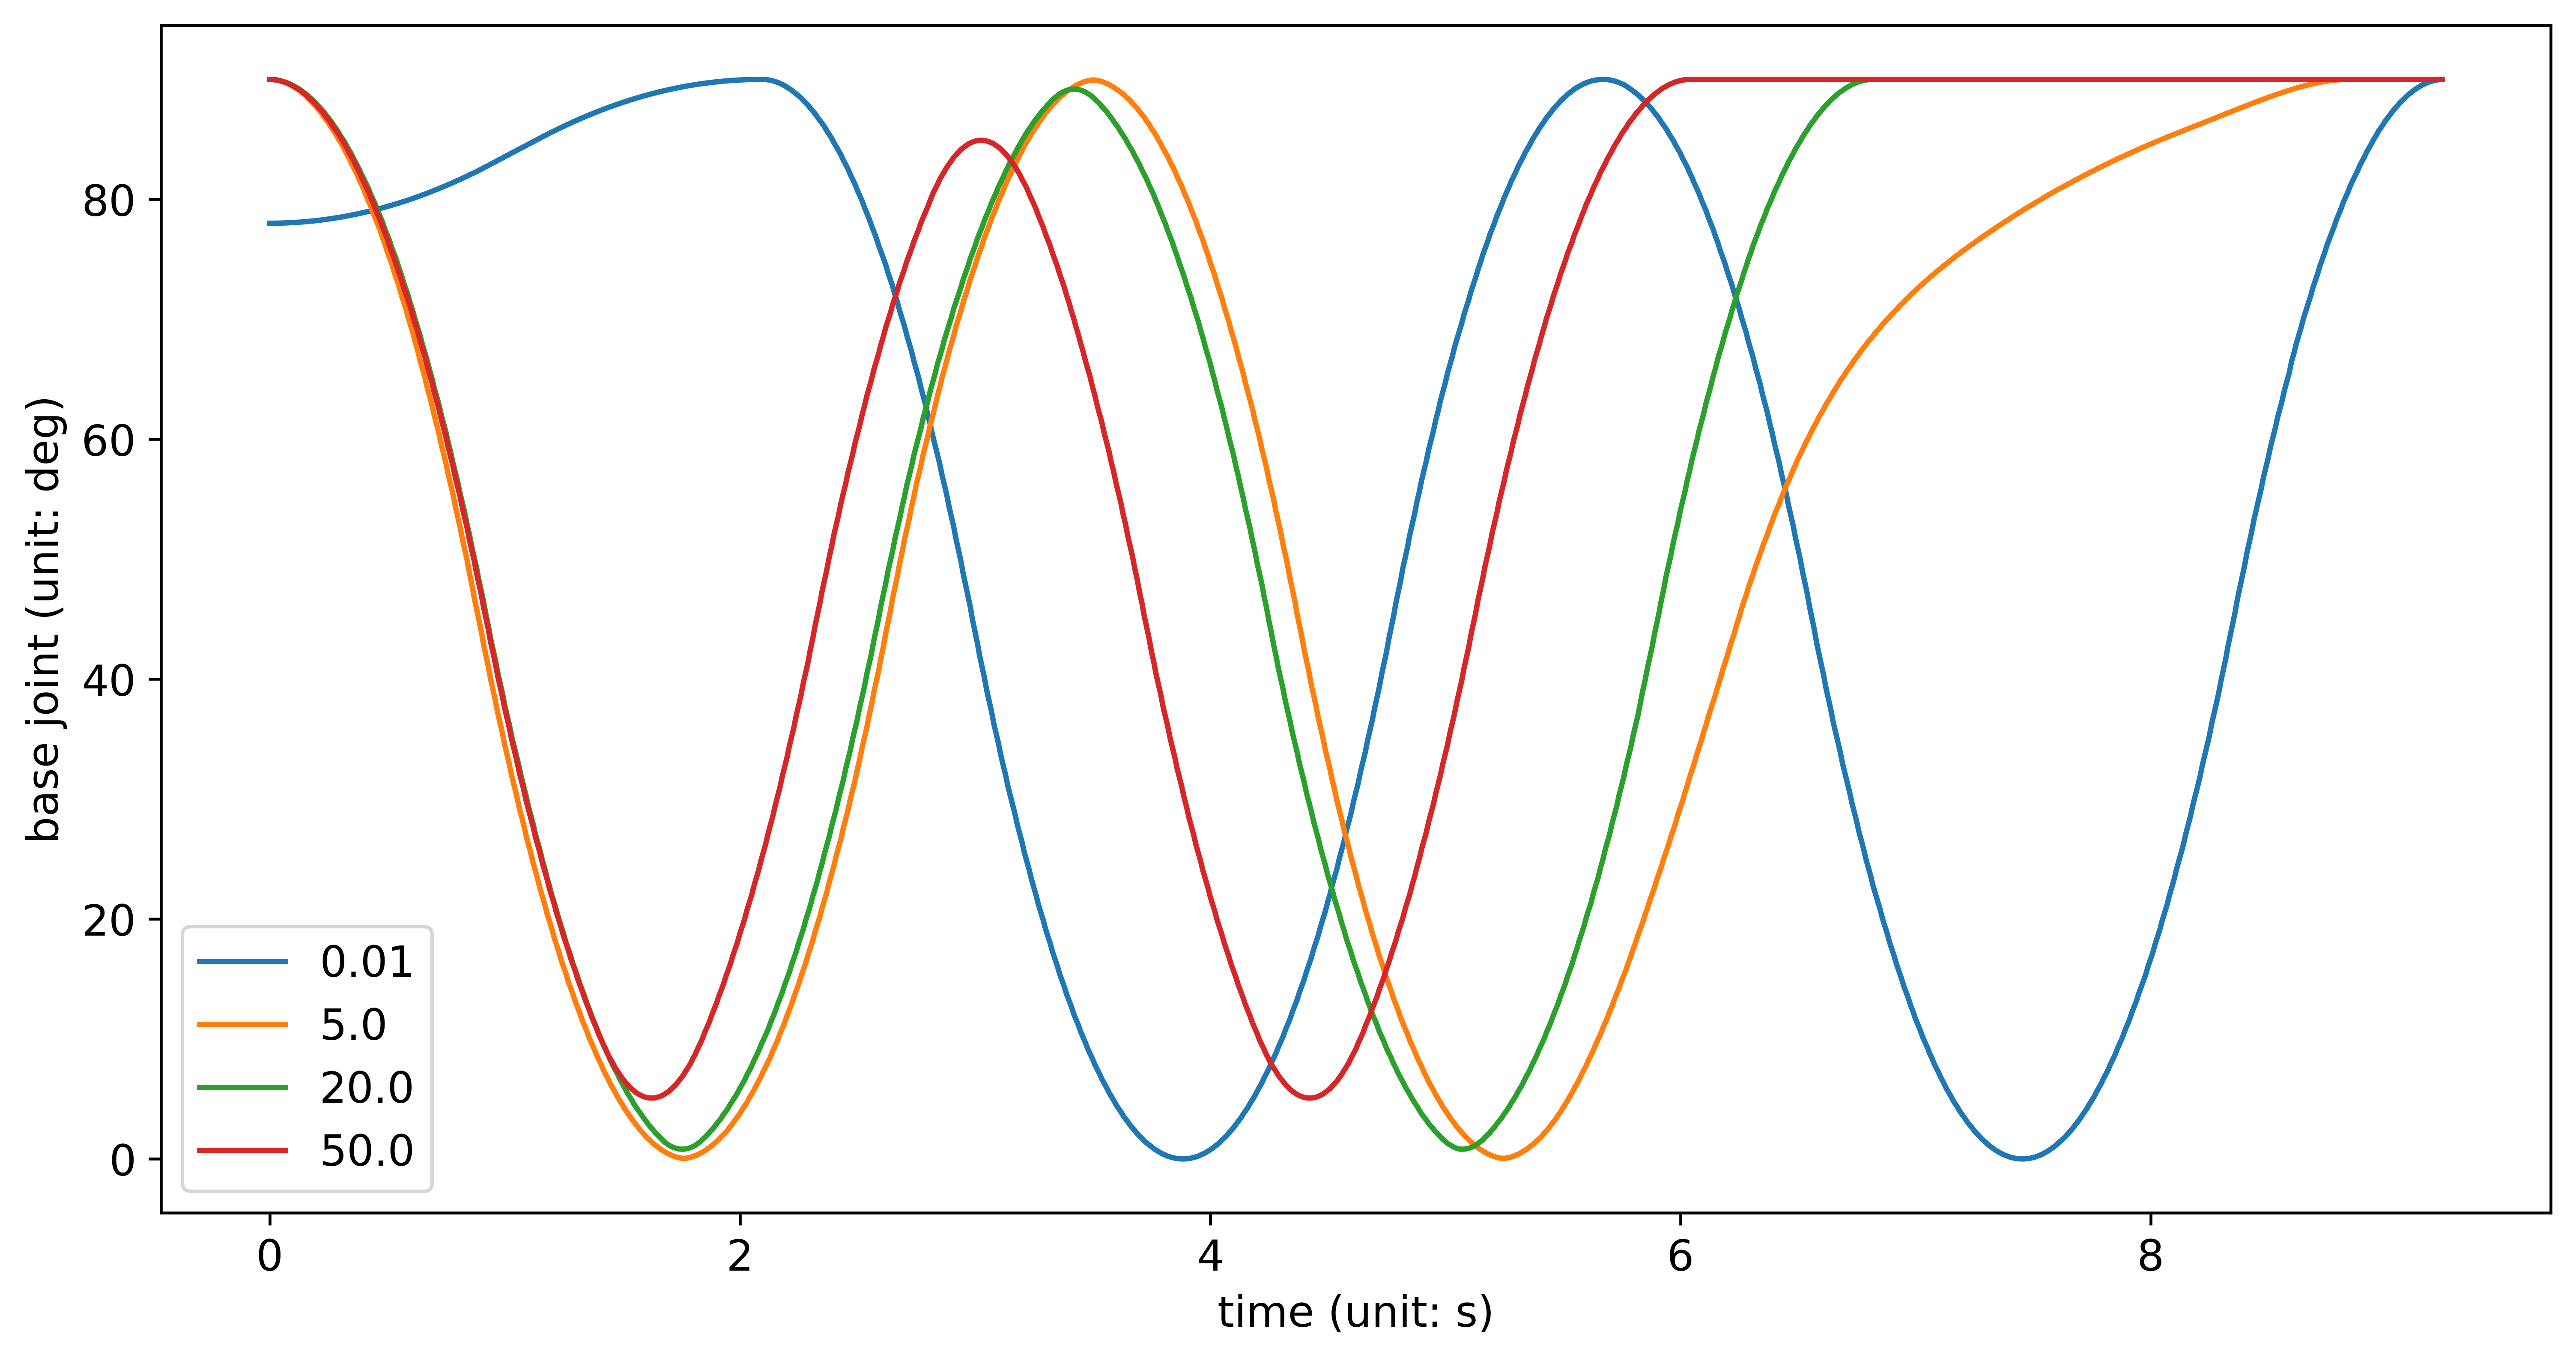

In [10]:
plt.figure(figsize=(12,6), facecolor='white', dpi=600)
plt.rcParams.update({'font.size': 12})

plt.plot(np.arange(0, q.shape[1]) * 0.01, np.transpose(q))
plt.xlabel('time (unit: s)')
plt.ylabel('base joint (unit: deg)')
plt.legend(blending_value)